#📌 Extracción

In [4]:
import pandas as pd
import json
import numpy as np

try:
    with open('TelecomX_Data.json', 'r') as f:
        data = json.load(f)

    # Normalizar (aplanar) el JSON para convertir objetos anidados en columnas
    df = pd.json_normalize(data)

    print("¡Datos cargados y normalizados correctamente!")
    print(f"Dimensiones del dataset: {df.shape}")

except Exception as e:
    print(f"Error al cargar datos: {e}")

df.head()

¡Datos cargados y normalizados correctamente!
Dimensiones del dataset: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

#🔧 Transformación

In [7]:
# 1. Manejo de 'Churn' vacío
# Contar vacíos
empty_churn = df[df['Churn'] == ""].shape[0]
print(f"Registros con Churn vacío encontrados: {empty_churn}")

# Eliminamos filas donde Churn es vacío, ya que no sirven para entrenar modelos predictivos
df_clean = df[df['Churn'] != ""].copy()

# 2. Manejo de 'TotalCharges' (account.Charges.Total)
# Convertir a numérico, forzando los errores (textos vacíos) a NaN
df_clean['account.Charges.Total'] = pd.to_numeric(df_clean['account.Charges.Total'], errors='coerce')

# Verificar cuántos nulos se generaron (generalmente son clientes con tenure=0)
null_charges = df_clean['account.Charges.Total'].isnull().sum()
print(f"Cargos totales nulos corregidos: {null_charges}")

# Rellenar los NaN con 0 (asumiendo que si no hay cobro total es porque acaban de empezar)
df_clean.fillna({'account.Charges.Total': 0}, inplace=True)

# Verificar duplicados
duplicates = df_clean.duplicated().sum()
print(f"Duplicados encontrados: {duplicates}")

Registros con Churn vacío encontrados: 224
Cargos totales nulos corregidos: 11
Duplicados encontrados: 0


In [8]:
# Crear columna de gasto diario
df_clean['Cuentas_Diarias'] = df_clean['account.Charges.Monthly'] / 30

# Redondear a 2 decimales para mejor lectura
df_clean['Cuentas_Diarias'] = df_clean['Cuentas_Diarias'].round(2)

print("\nEjemplo de nueva columna Cuentas_Diarias:")
print(df_clean[['account.Charges.Monthly', 'Cuentas_Diarias']].head(3))


Ejemplo de nueva columna Cuentas_Diarias:
   account.Charges.Monthly  Cuentas_Diarias
0                     65.6             2.19
1                     59.9             2.00
2                     73.9             2.46


In [9]:
# 1. Diccionario de traducción y renombrado
column_mapping = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Jubilado',
    'customer.Partner': 'Pareja',
    'customer.Dependents': 'Dependientes',
    'customer.tenure': 'Meses_Permanencia',
    'phone.PhoneService': 'Servicio_Telefonico',
    'phone.MultipleLines': 'Multiples_Lineas',
    'internet.InternetService': 'Servicio_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Copia_Seguridad',
    'internet.DeviceProtection': 'Proteccion_Dispositivo',
    'internet.TechSupport': 'Soporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Peliculas',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Facturacion_Sin_Papel',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Cargos_Mensuales',
    'account.Charges.Total': 'Cargos_Totales'
}

# Aplicar renombrado
df_final = df_clean.rename(columns=column_mapping)

# 2. Transformación de valores a binarios (Mapping)
# Estandarizamos 'Abandono' para análisis numérico
binary_map = {'Yes': 1, 'No': 0}
df_final['Abandono_Binario'] = df_final['Abandono'].map(binary_map)

# También podemos traducir el Género para consistencia
gender_map = {'Female': 'Femenino', 'Male': 'Masculino'}
df_final['Genero'] = df_final['Genero'].map(gender_map)

# Reordenar columnas para poner el Target al principio o final según preferencia
cols = ['ID_Cliente', 'Abandono', 'Abandono_Binario'] + [c for c in df_final.columns if c not in ['ID_Cliente', 'Abandono', 'Abandono_Binario']]
df_final = df_final[cols]

# Resultado Final
print("\n--- INFO DEL DATASET PROCESADO ---")
df_final.info()

print("\n--- MUESTRA DE DATOS FINALES ---")
print(df_final.head())


--- INFO DEL DATASET PROCESADO ---
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7043 non-null   object 
 1   Abandono                7043 non-null   object 
 2   Abandono_Binario        7043 non-null   int64  
 3   Genero                  7043 non-null   object 
 4   Jubilado                7043 non-null   int64  
 5   Pareja                  7043 non-null   object 
 6   Dependientes            7043 non-null   object 
 7   Meses_Permanencia       7043 non-null   int64  
 8   Servicio_Telefonico     7043 non-null   object 
 9   Multiples_Lineas        7043 non-null   object 
 10  Servicio_Internet       7043 non-null   object 
 11  Seguridad_Online        7043 non-null   object 
 12  Copia_Seguridad         7043 non-null   object 
 13  Proteccion_Dispositivo  7043 non-null   object 
 14  Soporte_T

#📊 Carga y análisis

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("--- 1. ANÁLISIS DESCRIPTIVO ---")

# Variables numéricas: media, desviación, cuartiles
print("\nResumen Estadístico (Variables Numéricas):")
desc_num = df_final.describe().T
print(desc_num[['mean', 'std', 'min', '50%', 'max']])
# Nota: '50%' es la mediana

# Variables categóricas: conteo, únicos, moda
print("\nResumen Estadístico (Variables Categóricas):")
desc_cat = df_final.describe(include=['object']).T
print(desc_cat)

--- 1. ANÁLISIS DESCRIPTIVO ---

Resumen Estadístico (Variables Numéricas):
                          mean          std    min      50%      max
Abandono_Binario      0.265370     0.441561   0.00     0.00     1.00
Jubilado              0.162147     0.368612   0.00     0.00     1.00
Meses_Permanencia    32.371149    24.559481   0.00    29.00    72.00
Cargos_Mensuales     64.761692    30.090047  18.25    70.35   118.75
Cargos_Totales     2279.734304  2266.794470   0.00  1394.55  8684.80
Cuentas_Diarias       2.158675     1.003088   0.61     2.34     3.96

Resumen Estadístico (Variables Categóricas):
                       count unique               top  freq
ID_Cliente              7043   7043        9995-HOTOH     1
Abandono                7043      2                No  5174
Genero                  7043      2         Masculino  3555
Pareja                  7043      2                No  3641
Dependientes            7043      2                No  4933
Servicio_Telefonico     7043      2


--- 2. DISTRIBUCIÓN DE LA EVASIÓN (CHURN) ---
No Abandono (No): 5174 (73.46%)
Abandono (Yes):   1869 (26.54%)


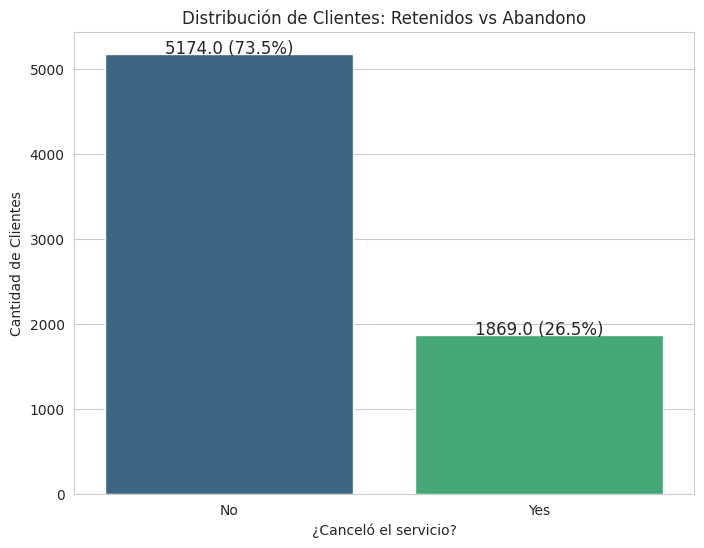

In [13]:
print("\n--- 2. DISTRIBUCIÓN DE LA EVASIÓN (CHURN) ---")

# Calcular porcentajes
churn_counts = df_final['Abandono'].value_counts()
churn_percentage = df_final['Abandono'].value_counts(normalize=True) * 100

print(f"No Abandono (No): {churn_counts['No']} ({churn_percentage['No']:.2f}%)")
print(f"Abandono (Yes):   {churn_counts['Yes']} ({churn_percentage['Yes']:.2f}%)")

# Visualización
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Abandono', data=df_final, hue='Abandono', palette='viridis', legend=False)

# Añadir etiquetas de porcentaje sobre las barras
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.1,
            f'{height} ({height/len(df_final):.1%})',
            ha="center", fontsize=12)

plt.title('Distribución de Clientes: Retenidos vs Abandono')
plt.xlabel('¿Canceló el servicio?')
plt.ylabel('Cantidad de Clientes')
plt.show()


--- 3. EVASIÓN POR VARIABLES CATEGÓRICAS ---


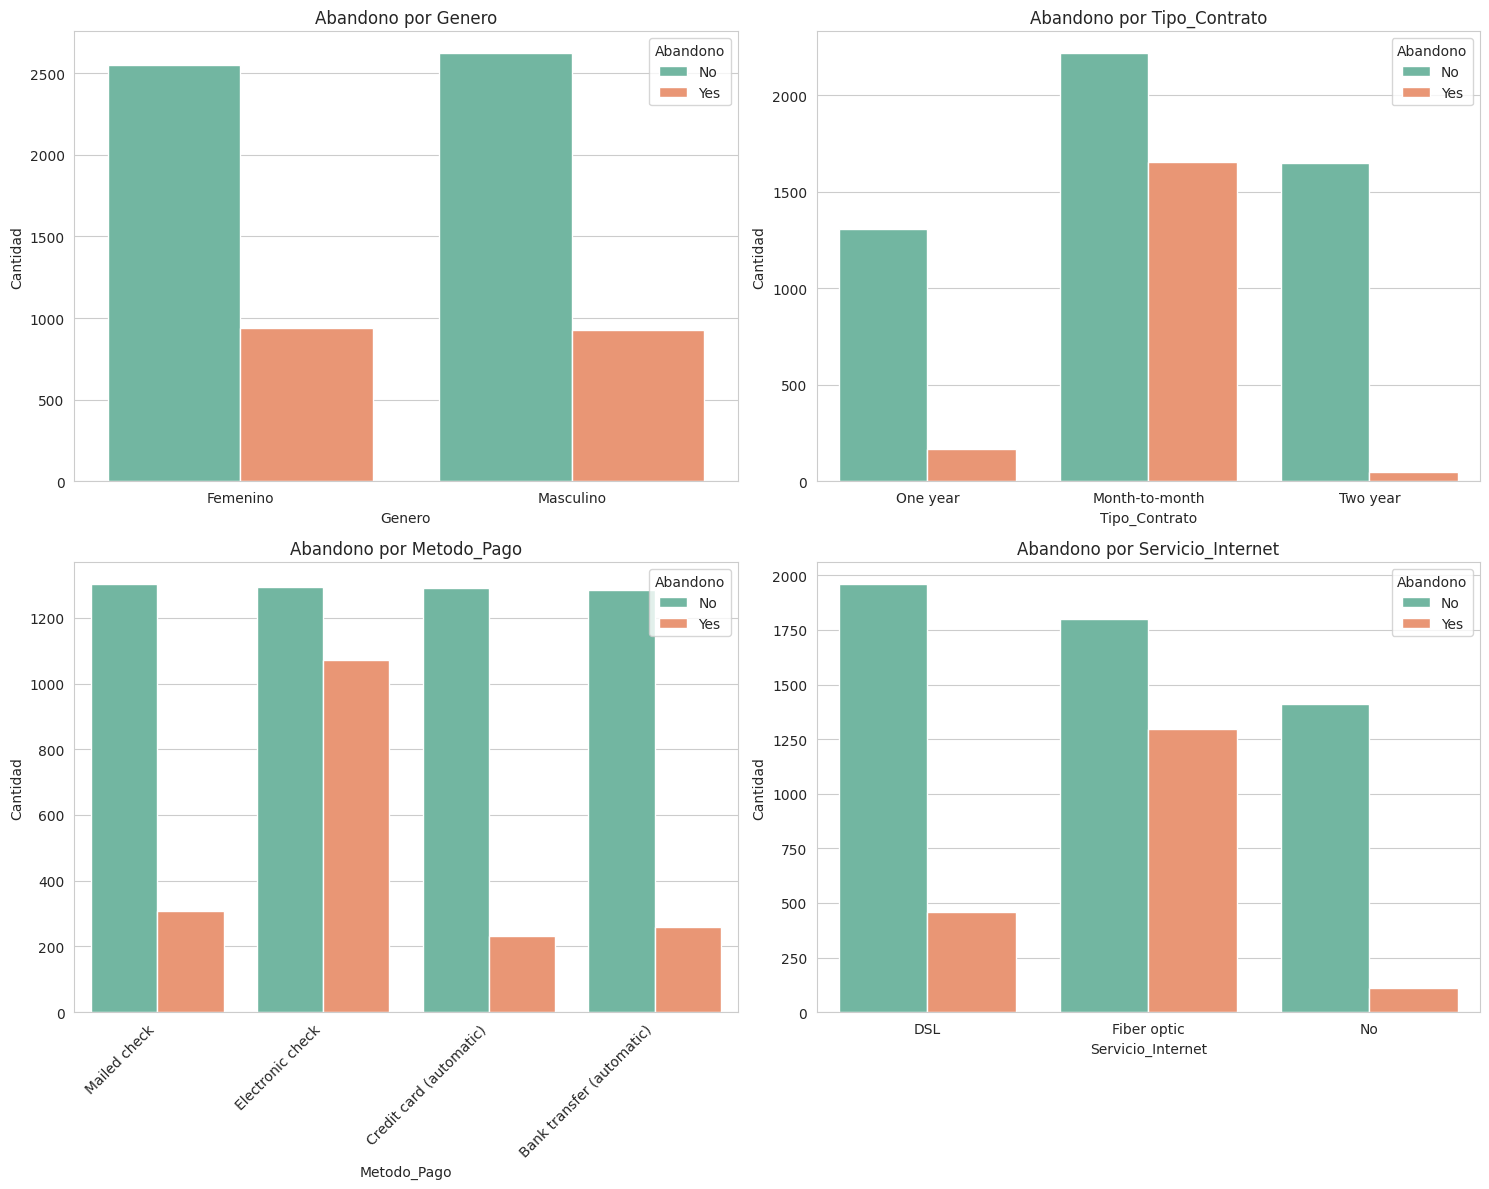

In [14]:
print("\n--- 3. EVASIÓN POR VARIABLES CATEGÓRICAS ---")

# Seleccionamos variables clave para analizar
vars_categoricas = ['Genero', 'Tipo_Contrato', 'Metodo_Pago', 'Servicio_Internet']

plt.figure(figsize=(15, 12))

for i, col in enumerate(vars_categoricas, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, hue='Abandono', data=df_final, palette='Set2')
    plt.title(f'Abandono por {col}')
    plt.xlabel(col)
    plt.ylabel('Cantidad')
    plt.legend(title='Abandono', loc='upper right')

    # Rotar etiquetas si son largas (especialmente para Método de Pago)
    if col == 'Metodo_Pago':
        plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


--- 4. EVASIÓN POR VARIABLES NUMÉRICAS ---


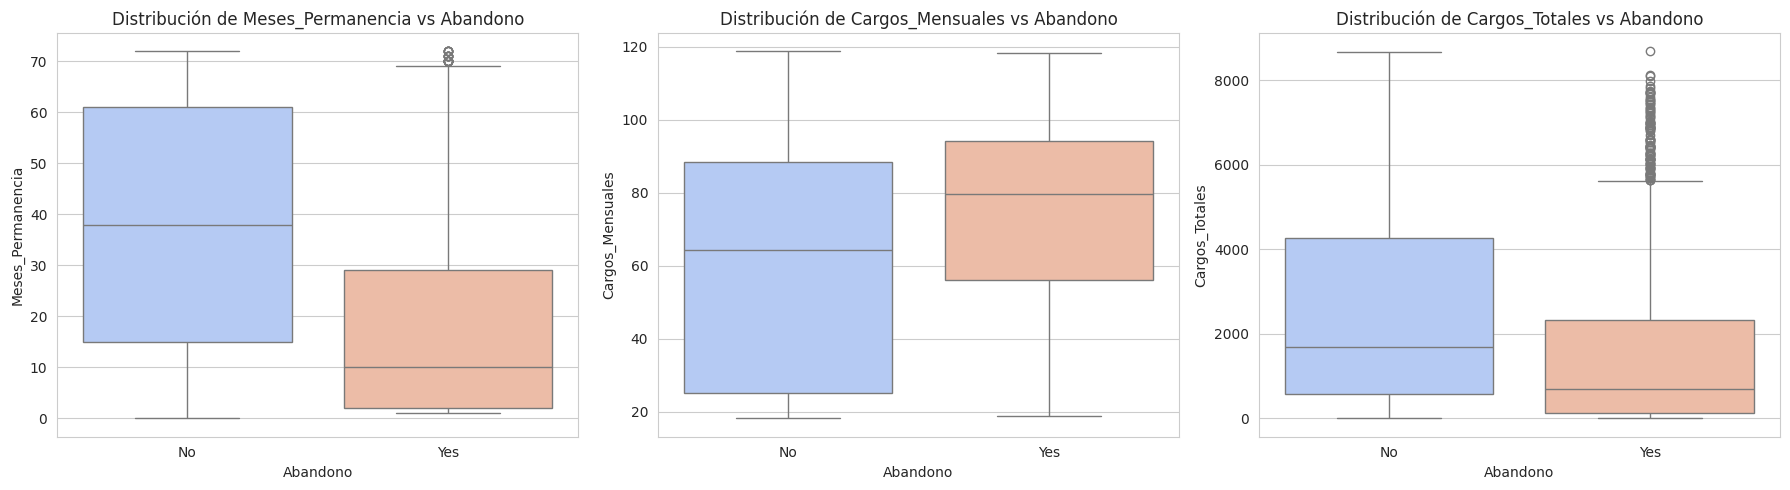

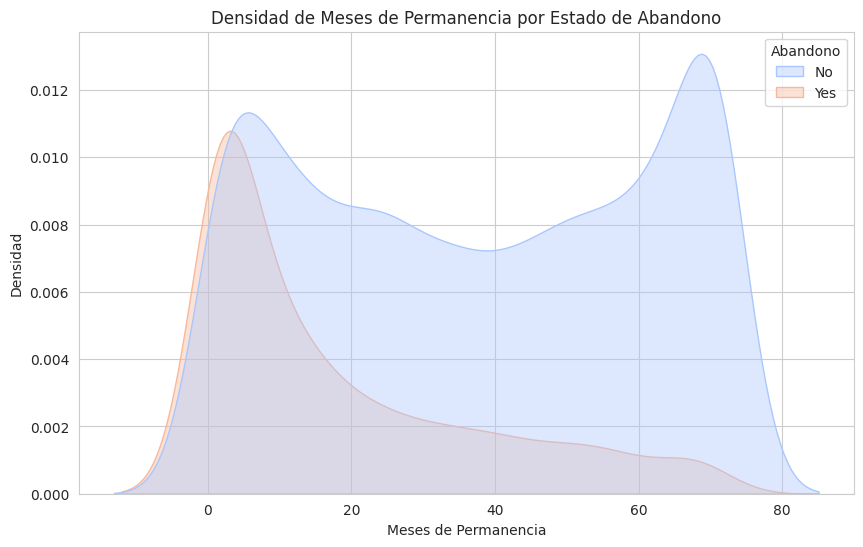

In [15]:
print("\n--- 4. EVASIÓN POR VARIABLES NUMÉRICAS ---")

# Usaremos Boxplots (Diagramas de Caja) para ver distribuciones y outliers
vars_numericas = ['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales']

plt.figure(figsize=(18, 5))

for i, col in enumerate(vars_numericas, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Abandono', y=col, data=df_final, hue='Abandono', palette='coolwarm', legend=False)
    plt.title(f'Distribución de {col} vs Abandono')
    plt.xlabel('Abandono')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

# Adicional: Gráfico de densidad (KDE) para ver la forma de la distribución de Permanencia
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_final, x='Meses_Permanencia', hue='Abandono', fill=True, palette='coolwarm', alpha=0.4)
plt.title('Densidad de Meses de Permanencia por Estado de Abandono')
plt.xlabel('Meses de Permanencia')
plt.ylabel('Densidad')
plt.show()

#📄Informe final

#  Informe Final: Análisis de Evasión de Clientes (Churn) - TelecomX

## 1. Introducción
El objetivo principal de este proyecto ha sido analizar el comportamiento de los clientes de la empresa de telecomunicaciones **TelecomX** para comprender el fenómeno del **Churn** (evasión o abandono de clientes).

La evasión de clientes representa un desafío crítico y costoso, ya que la adquisición de nuevos usuarios requiere una inversión significativamente mayor que la retención de los existentes. A través de este análisis, buscamos identificar patrones, tendencias y factores determinantes que influyen en la decisión de cancelar el servicio, con el fin de proponer estrategias basadas en datos para mitigar estas pérdidas.

## 2. Limpieza y Tratamiento de Datos
Para asegurar la fiabilidad del análisis, se llevó a cabo un riguroso proceso de extracción, transformación y carga (ETL):

*   **Ingesta y Normalización:** Se importó un archivo JSON anidado y se utilizó `pd.json_normalize` para aplanar la estructura y convertirla en un formato tabular manejable.
*   **Manejo de Datos Faltantes:**
    *   Se identificaron registros con la variable objetivo `Churn` vacía y se eliminaron, ya que no aportan valor al aprendizaje supervisado.
    *   Se corrigió la columna `account.Charges.Total`, convirtiéndola a numérica y rellenando los valores nulos (generados por clientes nuevos con `tenure=0`) con el valor `0`.
*   **Ingeniería de Características:**
    *   Se tradujeron las columnas al español para facilitar la interpretación (ej. `tenure` a `Meses_Permanencia`).
    *   Se creó la variable `Abandono_Binario` (1/0) para facilitar cálculos estadísticos.
    *   Se generó una nueva variable `Cuentas_Diarias` para analizar el impacto del gasto diario en la retención.

## 3. Análisis Exploratorio de Datos (EDA)
Mediante técnicas estadísticas y visualización gráfica, se exploraron las relaciones entre las variables y la tasa de abandono:

*   **Distribución General:** Se observó que el dataset está desbalanceado (típico en problemas de churn), con una mayoría de clientes retenidos, pero con una tasa de abandono lo suficientemente alta (~26%) como para requerir intervención.
*   **Análisis Univariado y Bivariado:**
    *   Se utilizaron gráficos de barras para comparar variables categóricas (Género, Contrato, Método de Pago) contra el estado de abandono.
    *   Se emplearon Boxplots (diagramas de caja) para visualizar la dispersión de variables numéricas (Cargos Mensuales, Permanencia) y detectar valores atípicos.

## 4. Conclusiones e Insights
Tras el análisis visual y descriptivo, se han identificado los siguientes patrones clave:

1.  **El Factor "Contrato":** Existe una correlación directa y fuerte entre los contratos de tipo **"Mes a mes"** y una alta tasa de abandono. Los clientes con contratos a 1 o 2 años muestran una lealtad significativamente superior.
2.  **La Vulnerabilidad de los Nuevos Clientes:** La variable `Meses_Permanencia` indica que la mayor fuga ocurre durante los primeros meses de vida del cliente. Superado el primer año, la probabilidad de abandono cae drásticamente.
3.  **Sensibilidad al Precio:** Los clientes que abandonan suelen tener, en promedio, **Cargos Mensuales** más altos que los que se quedan. Esto sugiere que el precio es un factor de fricción importante.
4.  **Método de Pago:** Los usuarios que pagan mediante **"Cheque electrónico"** presentan la tasa de deserción más alta en comparación con métodos automáticos (tarjetas o transferencias).

## 5. Recomendaciones Estratégicas
Basado en los hallazgos, se sugieren las siguientes acciones para reducir la tasa de Churn:

*   **Incentivar Contratos a Largo Plazo:** Diseñar campañas agresivas para migrar clientes de "Mes a mes" a contratos anuales, ofreciendo descuentos o beneficios exclusivos (ej. mayor velocidad o servicios de streaming incluidos).
*   **Programa de Retención Temprana (Onboarding):** Implementar un seguimiento proactivo durante los primeros 6 meses del cliente, asegurando que entienden el servicio y resolviendo incidencias rápidamente para evitar la fuga temprana.
*   **Promoción de Pagos Automáticos:** Incentivar a los usuarios de "Cheque electrónico" a cambiar a pagos domiciliados (tarjeta o cuenta bancaria), quizás ofreciendo un descuento único en la factura, para aumentar la inercia de permanencia.
*   **Revisión de Valor en Segmentos de Alto Costo:** Para los clientes con facturas mensuales altas, evaluar si están recibiendo un valor percibido adecuado y ofrecer paquetes personalizados para evitar que busquen alternativas más baratas en la competencia.